In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(color_codes=True)

from google.colab import files
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn import metrics
import math



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/Clean_Dataset.csv'
df = pd.read_csv(file_path)
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
df2 = df.drop(columns=['Unnamed: 0','flight'])
df2

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


<Axes: xlabel='airline', ylabel='price'>

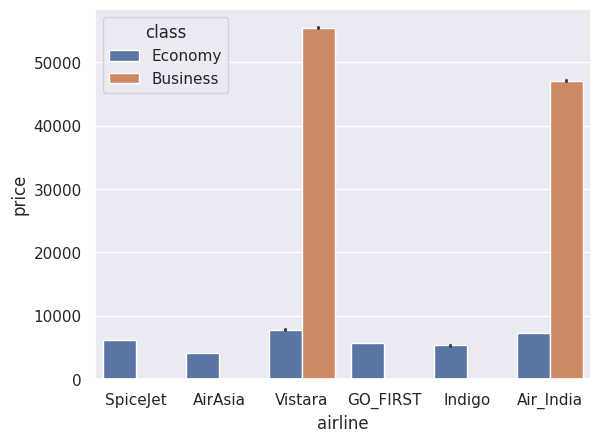

In [ ]:
sns.barplot(data=df, x="airline",y="price", hue="class")

<Axes: xlabel='airline', ylabel='duration'>

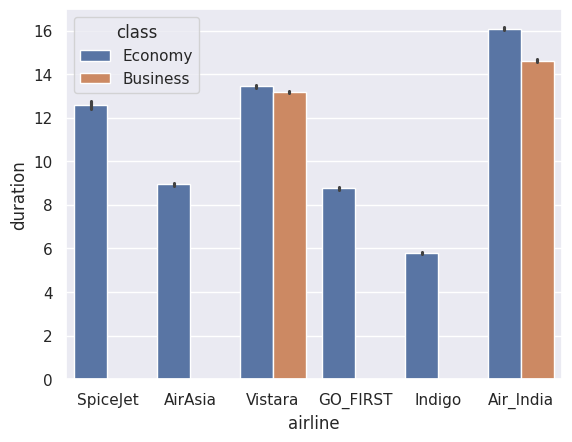

In [ ]:
sns.barplot(data=df, x="airline",y="duration", hue="class")

<Axes: xlabel='stops', ylabel='price'>

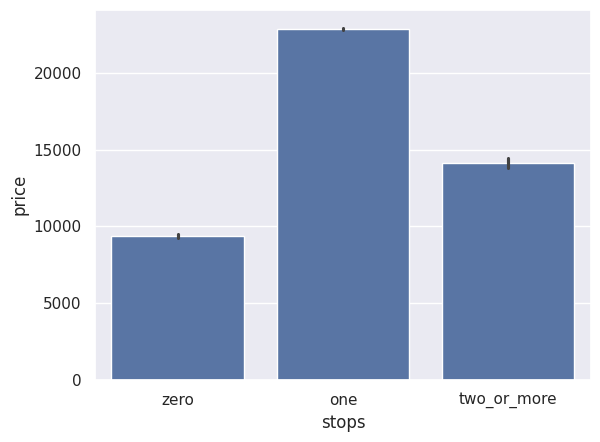

In [ ]:
sns.barplot(data=df, x="stops", y="price")

<Axes: xlabel='stops', ylabel='count'>

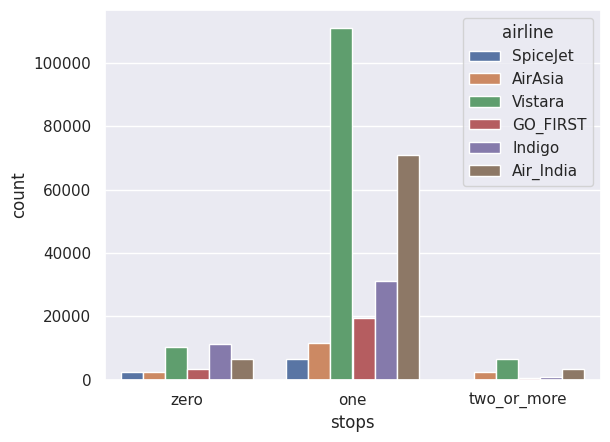

In [ ]:
sns.countplot(data=df, x="stops", hue="airline")

<Axes: xlabel='destination_city', ylabel='price'>

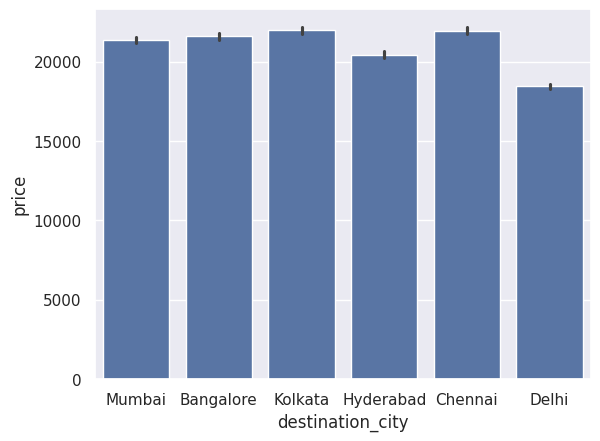

In [ ]:
sns.barplot(data=df, x="destination_city", y="price")


In [ ]:
df['source_city'].unique()

array(['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai'],
      dtype=object)

In [ ]:
df['departure_time'].unique()

array(['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night',
       'Late_Night'], dtype=object)

In [ ]:
df['arrival_time'].unique()

array(['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening',
       'Late_Night'], dtype=object)

In [ ]:
df['destination_city'].unique()

array(['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi'],
      dtype=object)

In [ ]:

df2['airline'] = df2['airline'].replace(['SpiceJet'],'0')
df2['airline'] = df2['airline'].replace(['AirAsia'],'1')
df2['airline'] = df2['airline'].replace(['Vistara'],'2')
df2['airline'] = df2['airline'].replace(['GO_FIRST'],'3')
df2['airline'] = df2['airline'].replace(['Indigo'],'4')
df2['airline'] = df2['airline'].replace(['Air_India'],'5')

df2['source_city'] = df2['source_city'].replace(['Delhi'],'0')
df2['source_city'] = df2['source_city'].replace(['Mumbai'],'1')
df2['source_city'] = df2['source_city'].replace(['Bangalore'],'2')
df2['source_city'] = df2['source_city'].replace(['Kolkata'],'3')
df2['source_city'] = df2['source_city'].replace(['Hyderabad'],'4')
df2['source_city'] = df2['source_city'].replace(['Chennai'],'5')

df2['departure_time'] = df2['departure_time'].replace(['Evening'],'0')
df2['departure_time'] = df2['departure_time'].replace(['Early_Morning'],'1')
df2['departure_time'] = df2['departure_time'].replace(['Morning'],'2')
df2['departure_time'] = df2['departure_time'].replace(['Afternoon'],'3')
df2['departure_time'] = df2['departure_time'].replace(['Night'],'4')
df2['departure_time'] = df2['departure_time'].replace(['Late_Night'],'5')

df2['stops'] = df2['stops'].replace(['zero'],'0')
df2['stops'] = df2['stops'].replace(['one'],'1')
df2['stops'] = df2['stops'].replace(['two_or_more'],'2')

df2['arrival_time'] = df2['arrival_time'].replace(['Evening'],'0')
df2['arrival_time'] = df2['arrival_time'].replace(['Early_Morning'],'1')
df2['arrival_time'] = df2['arrival_time'].replace(['Morning'],'2')
df2['arrival_time'] = df2['arrival_time'].replace(['Afternoon'],'3')
df2['arrival_time'] = df2['arrival_time'].replace(['Night'],'4')
df2['arrival_time'] = df2['arrival_time'].replace(['Late_Night'],'5')

df2['destination_city'] = df2['destination_city'].replace(['Delhi'],'0')
df2['destination_city'] = df2['destination_city'].replace(['Mumbai'],'1')
df2['destination_city'] = df2['destination_city'].replace(['Bangalore'],'2')
df2['destination_city'] = df2['destination_city'].replace(['Kolkata'],'3')
df2['destination_city'] = df2['destination_city'].replace(['Hyderabad'],'4')
df2['destination_city'] = df2['destination_city'].replace(['Chennai'],'5')

df2['class'] = df2['class'].replace(['Economy'],'0')
df2['class'] = df2['class'].replace(['Business'],'1')
df2.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,2,0,4,0,0,1,0,2.17,1,5953
1,2,0,2,0,1,1,0,2.33,1,5953
2,0,0,2,0,2,1,0,2.17,1,5956
3,3,0,1,0,3,1,0,2.25,1,5955
4,3,0,1,0,1,1,0,2.33,1,5955


In [ ]:
df2.dtypes

,0
airline,int64
source_city,int64
departure_time,int64
stops,int64
arrival_time,int64
destination_city,int64
class,int64
duration,float64
days_left,int64
price,int64


In [ ]:
df2['airline'] = pd.to_numeric(df2['airline'])
df2['source_city'] = pd.to_numeric(df2['source_city'])
df2['departure_time'] = pd.to_numeric(df2['departure_time'])
df2['stops'] = pd.to_numeric(df2['stops'])
df2['arrival_time'] = pd.to_numeric(df2['arrival_time'])
df2['destination_city'] = pd.to_numeric(df2['destination_city'])
df2['class'] = pd.to_numeric(df2['class'])
df2.dtypes

,0
airline,int64
source_city,int64
departure_time,int64
stops,int64
arrival_time,int64
destination_city,int64
class,int64
duration,float64
days_left,int64
price,int64


<Axes: >

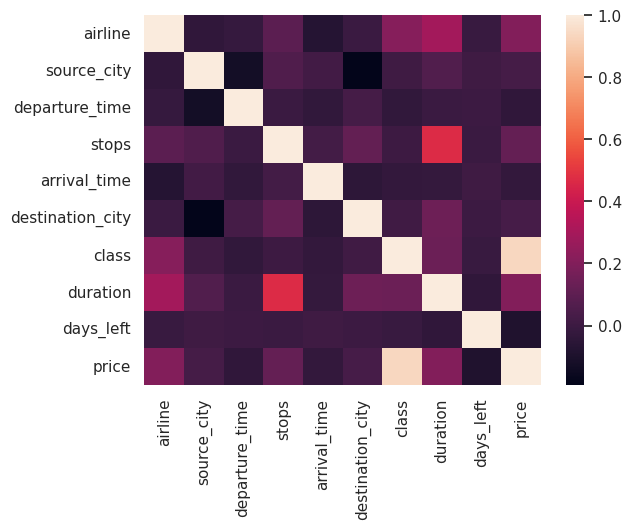

In [ ]:
sns.heatmap(df2.corr(), fmt='.2g')

In [ ]:
X = df2.drop('price', axis=1)
y = df2['price']

In [ ]:
#test size 20% and train size 80%
from sklearn.model_selection import train_test_split,cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                            test_size=0.2,random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtree = DecisionTreeRegressor(random_state=0)
dtree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
y_pred = dtree.predict(X_test)

In [ ]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = math.sqrt(mse)

print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))

MAE is 1144.6848628208759
MSE is 11603854.0463964
R2 score is 0.9773060136794447


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

In [ ]:
from sklearn import metrics
import math
y_pred = rf.predict(X_test)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = math.sqrt(mse)

print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))
print('RMSE score is {}'.format(rmse))

MAE is 1069.4324439498587
MSE is 7323615.80212035
R2 score is 0.9856769969558574
RMSE score is 2706.2179886550807
